<a href="https://colab.research.google.com/github/Mai732/ML-AI/blob/main/assignment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PART 1: DATA PREPARATION AND EDA

1. Dataset Shape:
Rows: 150, Columns: 6

2. Column Names and Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name          object
dtype: object

3. First 10 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4 

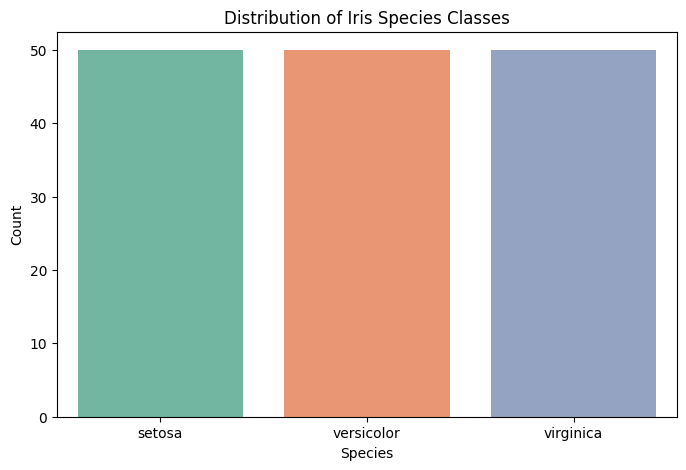

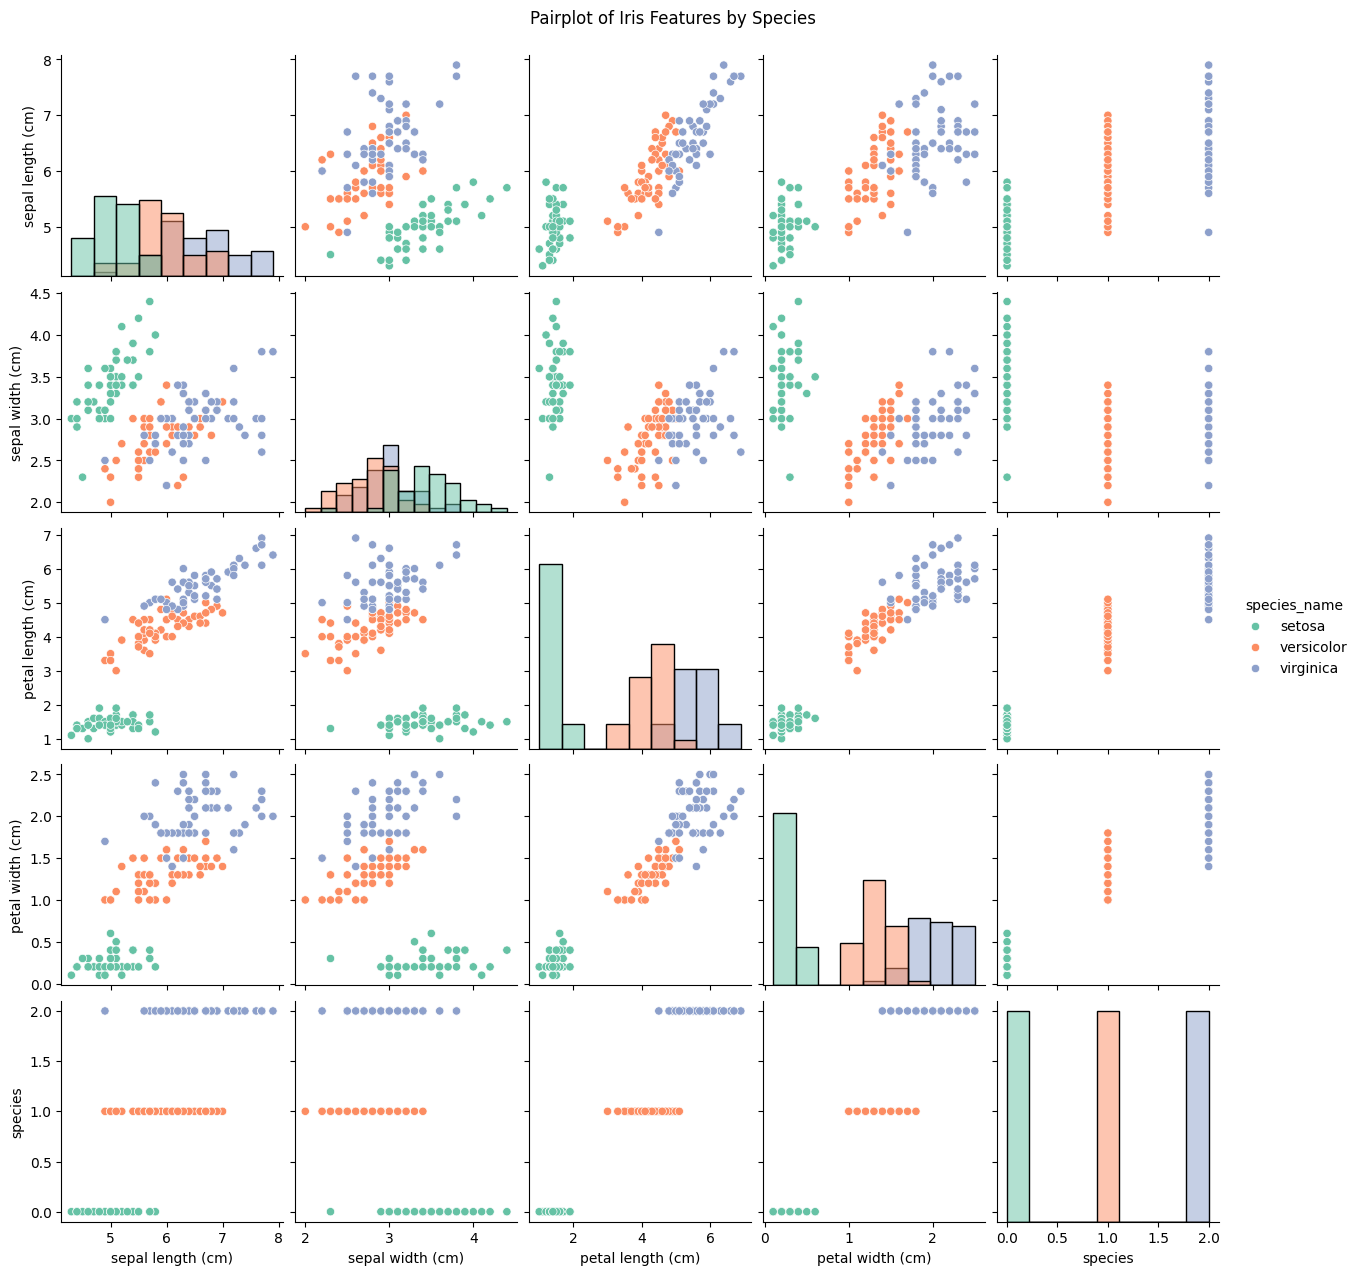


DATA SPLITTING AND SCALING

Training set size: 120 samples
Testing set size: 30 samples

Features scaled successfully!
Training data mean (after scaling): [-0. -0.  0.  0.]
Training data std (after scaling): [1. 1. 1. 1.]


In [ ]:

# PART 1: Import Libraries and Data Preparation

# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import sklearn components
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# Set random seed for reproducibility
np.random.seed(42)

# ============================================
# Load and Explore the Iris Dataset
# ============================================

# Load the iris dataset
iris = load_iris()

# Convert to pandas DataFrame for easier exploration
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = iris.target_names[iris.target]

# Display basic information about the dataset
print("="*60)
print("PART 1: DATA PREPARATION AND EDA")
print("="*60)

print("\n1. Dataset Shape:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n2. Column Names and Data Types:")
print(df.dtypes)

print("\n3. First 10 rows of the dataset:")
print(df.head(10))

print("\n4. Summary Statistics:")
print(df.describe())

print("\n5. Class Distribution:")
print(df['species_name'].value_counts())

# Visualize class distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='species_name', palette='Set2')
plt.title('Distribution of Iris Species Classes')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

# Visualize features using pairplot
sns.pairplot(df, hue='species_name', diag_kind='hist', palette='Set2')
plt.suptitle('Pairplot of Iris Features by Species', y=1.02)
plt.show()

# ============================================
# Prepare Data for Modeling
# ============================================

print("\n" + "="*60)
print("DATA SPLITTING AND SCALING")
print("="*60)

# Separate features (X) and target (y)
X = iris.data  # Features: sepal length, sepal width, petal length, petal width
y = iris.target  # Target: 0=setosa, 1=versicolor, 2=virginica

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Create the scaler object BEFORE using it
scaler = StandardScaler()

# Apply feature scaling using StandardScaler
# This helps the algorithms converge faster and perform better
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully!")
print("Training data mean (after scaling):", X_train_scaled.mean(axis=0).round(3))
print("Training data std (after scaling):", X_train_scaled.std(axis=0).round(3))








PART 2: ONE-VS-REST (OVR) LOGISTIC REGRESSION

Training OVR model...

OVR Model Evaluation:
Accuracy: 0.9000
Precision: 0.9024
Recall: 0.9000
F1-Score: 0.8997

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



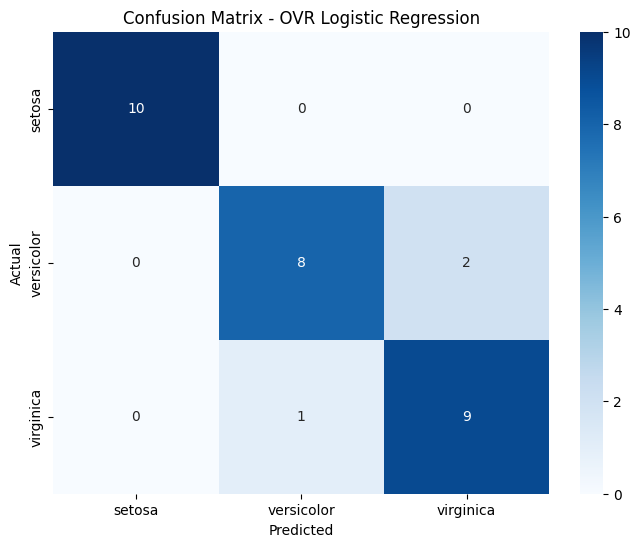

In [ ]:
# ============================================
# PART 2: ONE-VS-REST (OVR) LOGISTIC REGRESSION
# ============================================

print("\n" + "="*60)
print("PART 2: ONE-VS-REST (OVR) LOGISTIC REGRESSION")
print("="*60)

# Create logistic regression model with OVR strategy
# OVR trains one classifier per class (3 classifiers for 3 classes)
# Each classifier learns to distinguish one class from all others
logreg_ovr = LogisticRegression(multi_class='ovr', max_iter=1000, random_state=42)

# Train the model on scaled training data
print("\nTraining OVR model...")
logreg_ovr.fit(X_train_scaled, y_train)

# Make predictions on test data
y_pred_ovr = logreg_ovr.predict(X_test_scaled)

# Calculate evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

accuracy_ovr = accuracy_score(y_test, y_pred_ovr)
precision_ovr = precision_score(y_test, y_pred_ovr, average='weighted')
recall_ovr = recall_score(y_test, y_pred_ovr, average='weighted')
f1_ovr = f1_score(y_test, y_pred_ovr, average='weighted')

print("\nOVR Model Evaluation:")
print(f"Accuracy: {accuracy_ovr:.4f}")
print(f"Precision: {precision_ovr:.4f}")
print(f"Recall: {recall_ovr:.4f}")
print(f"F1-Score: {f1_ovr:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ovr, target_names=iris.target_names))

# Plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_ovr = confusion_matrix(y_test, y_pred_ovr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ovr, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - OVR Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Training OVO model...

OVO Model Evaluation:
Accuracy: 0.9667
Precision: 0.9697
Recall: 0.9667
F1-Score: 0.9666

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



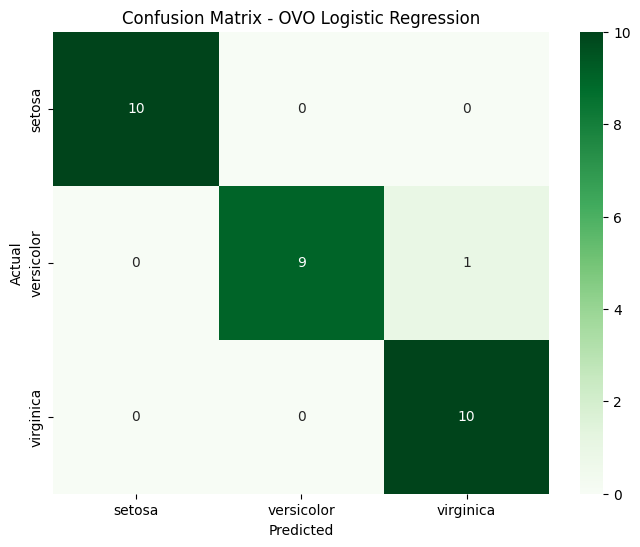

In [ ]:
# PART 3: ONE-VS-ONE (OVO) LOGISTIC REGRESSION

# Create OVO classifier using OneVsOneClassifier
# OVO trains one classifier for each pair of classes
# For 3 classes, it trains 3*(3-1)/2 = 3 classifiers
logreg_ovo = OneVsOneClassifier(LogisticRegression(max_iter=1000, random_state=42))

# Train the model
print("\nTraining OVO model...")
logreg_ovo.fit(X_train_scaled, y_train)

# Make predictions
y_pred_ovo = logreg_ovo.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy_ovo = accuracy_score(y_test, y_pred_ovo)
precision_ovo = precision_score(y_test, y_pred_ovo, average='weighted')
recall_ovo = recall_score(y_test, y_pred_ovo, average='weighted')
f1_ovo = f1_score(y_test, y_pred_ovo, average='weighted')

print("\nOVO Model Evaluation:")
print(f"Accuracy: {accuracy_ovo:.4f}")
print(f"Precision: {precision_ovo:.4f}")
print(f"Recall: {recall_ovo:.4f}")
print(f"F1-Score: {f1_ovo:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ovo, target_names=iris.target_names))

# Plot confusion matrix
cm_ovo = confusion_matrix(y_test, y_pred_ovo)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ovo, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - OVO Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Training SVM models with different kernels...


--- SVM with LINEAR kernel ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



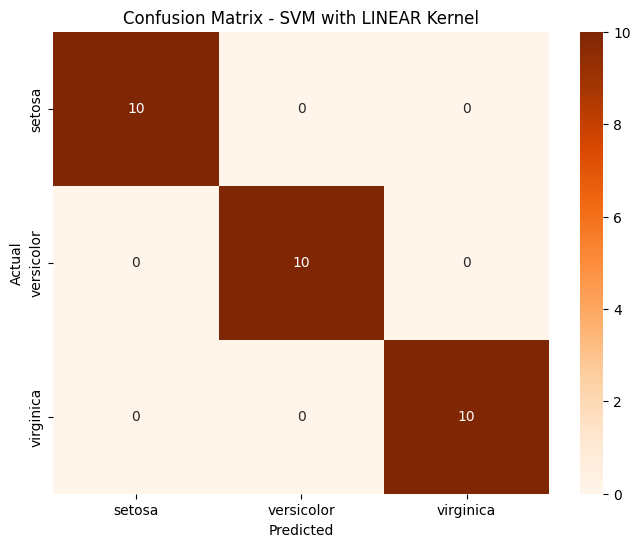


--- SVM with POLY kernel ---
Accuracy: 0.9000
Precision: 0.9231
Recall: 0.9000
F1-Score: 0.8977

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.77      1.00      0.87        10
   virginica       1.00      0.70      0.82        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



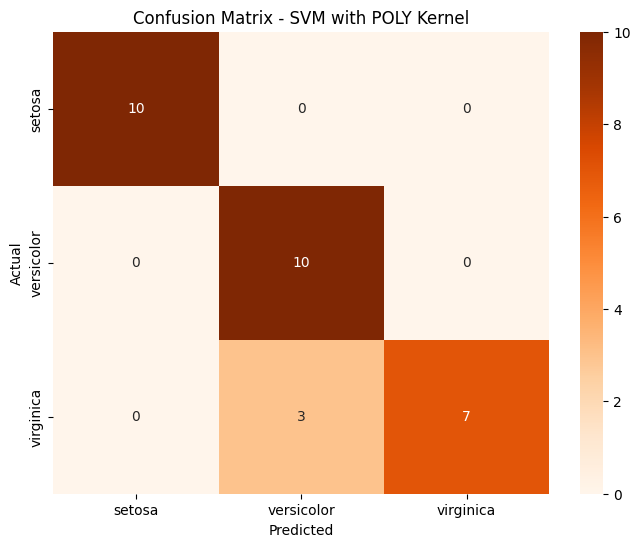


--- SVM with RBF kernel ---
Accuracy: 0.9667
Precision: 0.9697
Recall: 0.9667
F1-Score: 0.9666

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



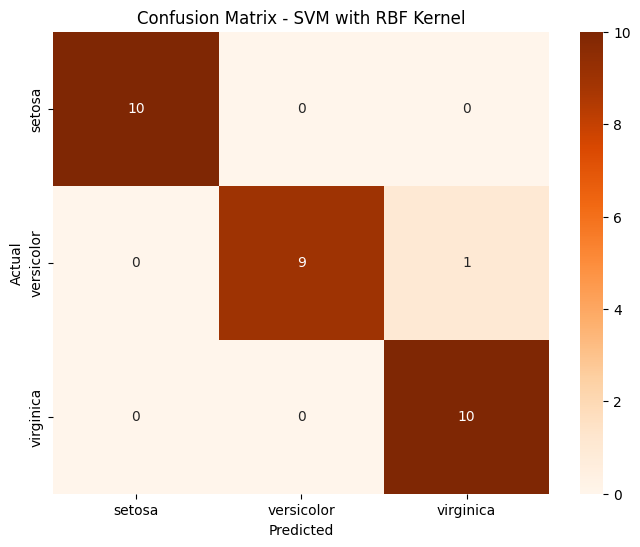

In [ ]:
# PART 4: SUPPORT VECTOR MACHINE (SVM) WITH DIFFERENT KERNELS
# Dictionary to store SVM models and their results
svm_models = {}
svm_results = {}

# Define kernels to test
kernels = ['linear', 'poly', 'rbf']

print("\nTraining SVM models with different kernels...\n")

for kernel in kernels:
    print(f"\n--- SVM with {kernel.upper()} kernel ---")

    # Create and train the SVM model
    if kernel == 'poly':
        svm = SVC(kernel=kernel, degree=3, random_state=42)
    else:
        svm = SVC(kernel=kernel, random_state=42)

    # Train the model
    svm.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred_svm = svm.predict(X_test_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred_svm)
    precision = precision_score(y_test, y_pred_svm, average='weighted')
    recall = recall_score(y_test, y_pred_svm, average='weighted')
    f1 = f1_score(y_test, y_pred_svm, average='weighted')

    # Store results
    svm_results[kernel] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': y_pred_svm
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_svm, target_names=iris.target_names))

    # Plot confusion matrix
    cm_svm = confusion_matrix(y_test, y_pred_svm)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=iris.target_names,
                yticklabels=iris.target_names)
    plt.title(f'Confusion Matrix - SVM with {kernel.upper()} Kernel')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [ ]:
# PART 5: MANUAL IMPLEMENTATION (OVR)

# using multiple binary logistic regression classifiers

from sklearn.linear_model import LogisticRegression

# Get unique classes
classes = np.unique(y_train)
n_classes = len(classes)

print(f"\nNumber of classes: {n_classes}")
print(f"Classes: {classes}")

print("\n1. Training binary classifiers for each class...")

binary_classifiers = {}

for class_label in classes:
    # Create binary labels: 1 if sample belongs to current class, 0 otherwise
    y_binary = (y_train == class_label).astype(int)

    # Train a binary logistic regression model
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train_scaled, y_binary)

    binary_classifiers[class_label] = clf
    print(f"   - Class {class_label} ({iris.target_names[class_label]}) classifier trained")

print("\n2. Making predictions using probability voting...")

# Get probability scores for each class
probabilities = []
for class_label in classes:
    # Get probability that sample belongs to this class
    prob = binary_classifiers[class_label].predict_proba(X_test_scaled)[:, 1]
    probabilities.append(prob)
probabilities = np.array(probabilities).T

# Predict the class with highest probability
y_pred_manual_ovr = np.argmax(probabilities, axis=1)

print("\n3. Evaluating manual OVR implementation...")

accuracy_manual_ovr = accuracy_score(y_test, y_pred_manual_ovr)
precision_manual_ovr = precision_score(y_test, y_pred_manual_ovr, average='weighted')
recall_manual_ovr = recall_score(y_test, y_pred_manual_ovr, average='weighted')
f1_manual_ovr = f1_score(y_test, y_pred_manual_ovr, average='weighted')

print(f"Accuracy: {accuracy_manual_ovr:.4f}")
print(f"Precision: {precision_manual_ovr:.4f}")
print(f"Recall: {recall_manual_ovr:.4f}")
print(f"F1-Score: {f1_manual_ovr:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_manual_ovr, target_names=iris.target_names))

# Compare with sklearn's OVR implementation
print("\n4. Comparing with sklearn's OVR implementation:")
print(f"Sklearn OVR Accuracy: {accuracy_ovr:.4f}")
print(f"Manual OVR Accuracy: {accuracy_manual_ovr:.4f}")

if accuracy_manual_ovr == accuracy_ovr:
    print("✓ Results match! Manual implementation is correct!")
else:
    print("Note: Results may differ slightly due to different implementation details")



Number of classes: 3
Classes: [0 1 2]

1. Training binary classifiers for each class...
   - Class 0 (setosa) classifier trained
   - Class 1 (versicolor) classifier trained
   - Class 2 (virginica) classifier trained

2. Making predictions using probability voting...

3. Evaluating manual OVR implementation...
Accuracy: 0.9000
Precision: 0.9024
Recall: 0.9000
F1-Score: 0.8997

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


4. Comparing with sklearn's OVR implementation:
Sklearn OVR Accuracy: 0.9000
Manual OVR Accuracy: 0.9000
✓ Results match! Manual implementation is correct!



Model Performance Comparison:
            Model  Accuracy  Precision  Recall  F1-Score  Number of Models
0    Logistic OVR    0.9000     0.9024  0.9000    0.8997                 3
1    Logistic OVO    0.9667     0.9697  0.9667    0.9666                 3
2      SVM Linear    1.0000     1.0000  1.0000    1.0000                 3
3  SVM Polynomial    0.9000     0.9231  0.9000    0.8977                 3
4         SVM RBF    0.9667     0.9697  0.9667    0.9666                 3


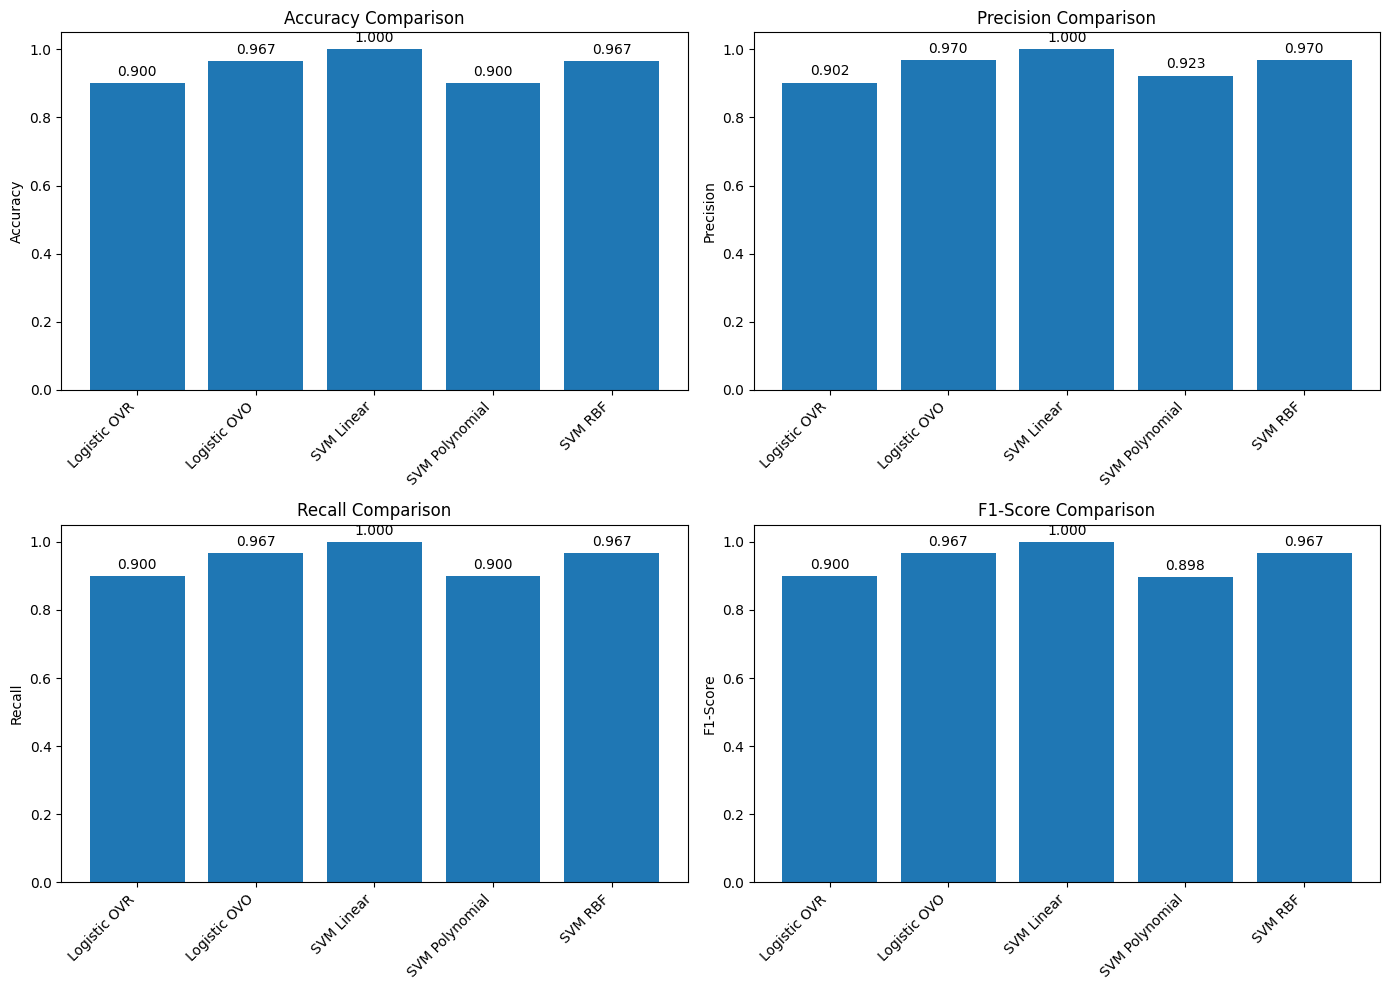

In [ ]:
# PART 6: COMPARISON AND ANALYSIS


# Create a comparison table
comparison_data = {
    'Model': ['Logistic OVR', 'Logistic OVO', 'SVM Linear', 'SVM Polynomial', 'SVM RBF'],
    'Accuracy': [accuracy_ovr, accuracy_ovo,
                 svm_results['linear']['accuracy'],
                 svm_results['poly']['accuracy'],
                 svm_results['rbf']['accuracy']],
    'Precision': [precision_ovr, precision_ovo,
                  svm_results['linear']['precision'],
                  svm_results['poly']['precision'],
                  svm_results['rbf']['precision']],
    'Recall': [recall_ovr, recall_ovo,
               svm_results['linear']['recall'],
               svm_results['poly']['recall'],
               svm_results['rbf']['recall']],
    'F1-Score': [f1_ovr, f1_ovo,
                 svm_results['linear']['f1'],
                 svm_results['poly']['f1'],
                 svm_results['rbf']['f1']],
    'Number of Models': [3, 3, 3, 3, 3]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Performance Comparison:")
print(comparison_df.round(4))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(comparison_df['Model'], comparison_df[metric])
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom')

plt.tight_layout()
plt.show()



Decision Boundaries (using first two features: sepal length and width):


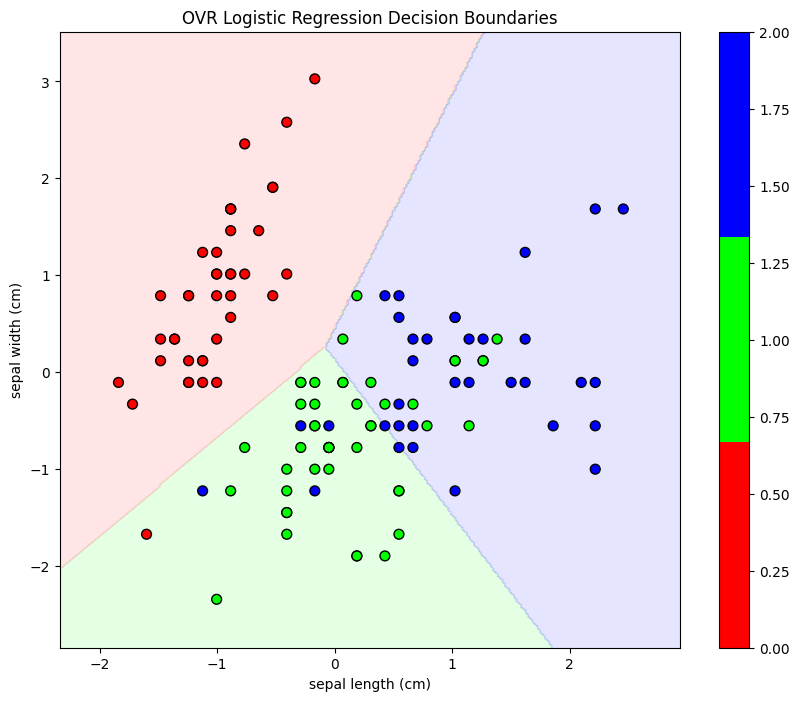

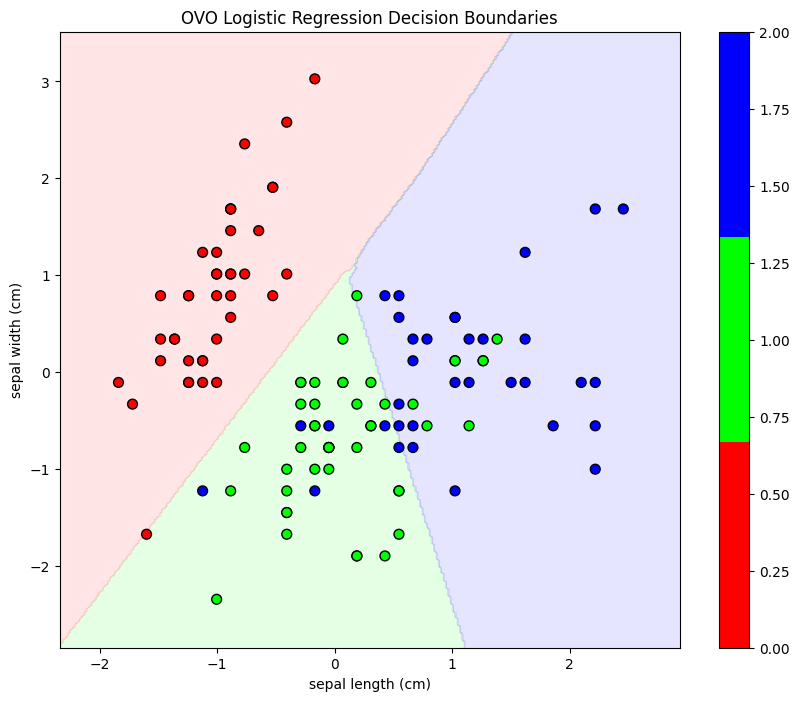

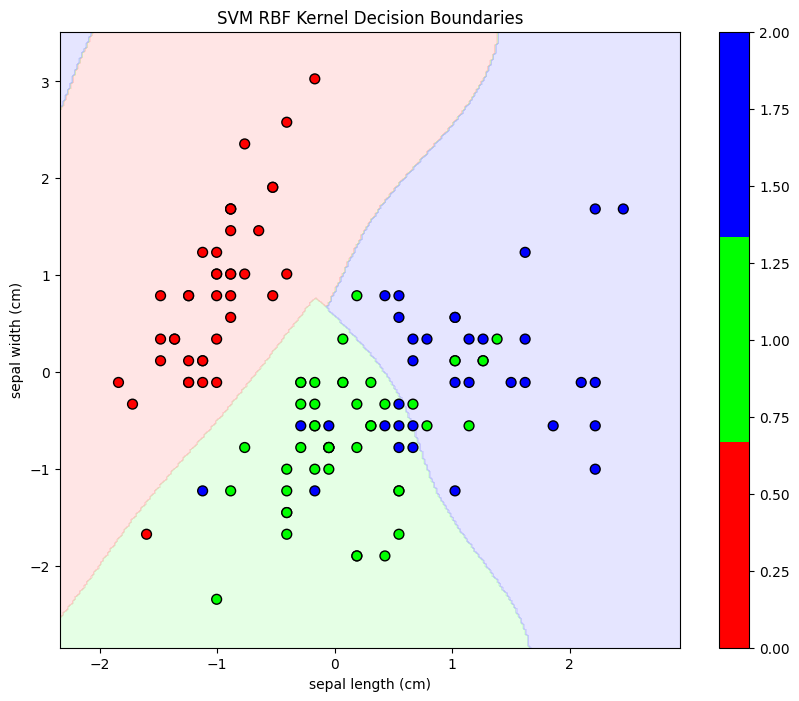

In [ ]:
# PART 7: viauilization

from matplotlib.colors import ListedColormap

def plot_decision_boundaries(X, y, model, title, feature_names):
    """Plot decision boundaries for 2D feature space"""
    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Make predictions on the mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Create color maps
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

    # Plot the decision boundary
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

    # Plot the training points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold,
                         edgecolor='black', s=50)

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(title)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.colorbar(scatter)
    plt.show()

# Train models on only first two features for visualization
X_train_2d = X_train_scaled[:, :2]
X_test_2d = X_test_scaled[:, :2]

# Train different models on 2D features
logreg_ovr_2d = LogisticRegression(multi_class='ovr', max_iter=1000, random_state=42)
logreg_ovr_2d.fit(X_train_2d, y_train)

logreg_ovo_2d = OneVsOneClassifier(LogisticRegression(max_iter=1000, random_state=42))
logreg_ovo_2d.fit(X_train_2d, y_train)

svm_rbf_2d = SVC(kernel='rbf', random_state=42)
svm_rbf_2d.fit(X_train_2d, y_train)

# Plot decision boundaries
print("\nDecision Boundaries (using first two features: sepal length and width):")
plot_decision_boundaries(X_train_2d, y_train, logreg_ovr_2d,
                        'OVR Logistic Regression Decision Boundaries',
                        iris.feature_names[:2])

plot_decision_boundaries(X_train_2d, y_train, logreg_ovo_2d,
                        'OVO Logistic Regression Decision Boundaries',
                        iris.feature_names[:2])

plot_decision_boundaries(X_train_2d, y_train, svm_rbf_2d,
                        'SVM RBF Kernel Decision Boundaries',
                        iris.feature_names[:2])

In [ ]:

# ANSWER REQUIRED QUESTIONS

print("\nQuestion 1: Why is OVO generally slower than OVR?")
print("OVO (One-vs-One) is generally slower than OVR (One-vs-Rest) because it trains significantly more individual classifiers,OVR trains 3 classifiersin this case.OVO trains 3 × (3-1) / 2 = 3 classifiers (the same number for 3 classes, but the difference grows quickly with more classes).")
print("\nQuestion2:Why can OVR introduce bias?")
print("because each binary classifier is trained on an imbalanced dataset.the classifier is trained to distinguish:Positive class: samples belonging to that specific class Negative class: ALL samples from all other classes combined")
print("\nQuestion3:How does class imbalance affect OVR and OVO?")
print("Effect on OVR:Class imbalance has a strong negative impact on OVR. Since each OVR classifier is trained on a one-vs-all setup, if the dataset is imbalanced, the negative class (all other classes combined) will dominate the training data")
print("Effect on OVO:Class imbalance affects OVO less severely. In OVO, each binary classifier only compares two specific classes at a time. This means:Each classifier is trained on a relatively more balanced dataset (only samples from the two classes being compared)")
